In [ ]:
# Setting up my Google Colab to have access to the files on my Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# These are the libraries used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os
import random

In [ ]:
# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(42)

In [ ]:
#Load Actual CICIDS2017 Data (Example using one file)
print("\nLoading and preprocessing actual CICIDS2017 data...")

cicids_file_path = '/content/drive/My Drive/Zero-Day Attack Detection/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'


Loading and preprocessing actual CICIDS2017 data...


In [ ]:
df_public_source = pd.DataFrame() # Initialize an empty DataFrame for public source
cicids_labels = pd.Series() # Initialize an empty Series for labels

In [ ]:
#Simulate Custom-Generated Financial Transaction Logs
print("Simulating custom financial transaction logs...")
num_financial_samples = 50000 # Increased for more realistic scale
num_financial_features = 7 # Example number of features for financial logs
np.random.seed(42)
benign_financial_data = np.random.randn(int(0.95 * num_financial_samples), num_financial_features) * 2 + 5
anomaly_financial_data = np.random.randn(int(0.05 * num_financial_samples), num_financial_features) * 5 - 10

df_financial = pd.DataFrame(np.vstack((benign_financial_data, anomaly_financial_data)),
                            columns=[f'fin_feat_{i}' for i in range(num_financial_features)])
print(f"Shape of simulated financial data: {df_financial.shape}")

Simulating custom financial transaction logs...
Shape of simulated financial data: (50000, 7)


In [ ]:
df_financial

,fin_feat_0,fin_feat_1,fin_feat_2,fin_feat_3,fin_feat_4,fin_feat_5,fin_feat_6
0,5.993428,4.723471,6.295377,8.046060,4.531693,4.531726,8.158426
1,6.534869,4.061051,6.085120,4.073165,4.068540,5.483925,1.173440
2,1.550164,3.875425,2.974338,5.628495,3.183952,2.175393,7.931298
3,4.548447,5.135056,2.150504,3.911235,5.221845,2.698013,5.751396
4,3.798723,4.416613,3.796587,8.704556,4.973006,2.884578,6.645090
...,...,...,...,...,...,...,...
49995,-8.747843,-12.833540,-13.253347,-10.275333,-8.637613,-7.275444,-9.370679
49996,-3.107478,-9.303138,-4.436214,-15.274100,-10.772501,-13.535580,-11.104461
49997,-10.248592,-6.719882,-16.314996,-14.649806,-8.181972,-18.189264,-11.253140
49998,-14.118038,-7.748725,-10.527023,-5.092509,-16.510111,-6.021381,-11.477422


# Data Preprocessing

In [ ]:
try:
    # Read the dataset, skipping bad lines if any
    df_cicids = pd.read_csv(cicids_file_path, encoding='latin1', low_memory=False)

    # --- Robust Preprocessing for CICIDS2017 ---
    # 1. Clean column names (strip spaces and remove potential trailing dots)
    df_cicids.columns = df_cicids.columns.str.strip().str.replace(r'\.$', '', regex=True)

    # 2. Handle 'Infinity' and NaN values immediately and robustly
    # Replace 'Infinity' (string) and actual np.inf with NaN
    df_cicids = df_cicids.replace([np.inf, -np.inf, 'Infinity', 'NaN'], np.nan)

    # 3. Handle categorical 'Label' column first
    if 'Label' in df_cicids.columns:
        df_cicids['Label'] = df_cicids['Label'].apply(lambda x: 0 if 'BENIGN' in str(x).upper() else 1)
        cicids_labels = df_cicids['Label']
        df_cicids_features = df_cicids.drop(columns=['Label'])
    else:
        print("Warning: 'Label' column not found in CICIDS2017 data. Assuming all unlabeled for now.")
        cicids_labels = pd.Series([0] * len(df_cicids)) # Dummy labels if not found
        df_cicids_features = df_cicids.copy()

    # 4. Convert all feature columns to numeric, coercing errors
    for col in df_cicids_features.columns:
        df_cicids_features[col] = pd.to_numeric(df_cicids_features[col], errors='coerce')

    # 5. Impute remaining NaNs *before* checking for zero variance
    # Use median imputation which is more robust to outliers than mean
    print("Filling NaNs in CICIDS2017 features with column median...")
    df_cicids_features = df_cicids_features.fillna(df_cicids_features.median())

    # If any column is still all NaN (e.g., if median was NaN for an all-NaN column), fill with 0
    df_cicids_features = df_cicids_features.fillna(0)

    # 6. Remove features with zero variance (constant features)
    print("Removing zero-variance features from CICIDS2017 data...")
    # Calculate variance, handle potential NaN variances if any column was still all NaN
    variances = df_cicids_features.var(numeric_only=True)
    constant_columns = [col for col, var in variances.items() if var == 0 or pd.isna(var)]
    if constant_columns:
        print(f"  Removed {len(constant_columns)} constant features: {constant_columns}")
        df_cicids_features = df_cicids_features.drop(columns=constant_columns)
    else:
        print("  No constant features found.")

    # 7. Final selection of numerical features (optional, but good for focus)
    # Ensure all selected features are actually numeric and not datetime/object types
    numeric_cols = df_cicids_features.select_dtypes(include=np.number).columns.tolist()
    if not numeric_cols:
        raise ValueError("No numeric columns found in CICIDS2017 features after preprocessing!")

    df_public_source = df_cicids_features[numeric_cols]

    # Sample a subset if the dataset is too large for memory/computation
    if len(df_public_source) > num_financial_samples * 1.5:
        df_public_source = df_public_source.sample(n=num_financial_samples, random_state=42).reset_index(drop=True)
        cicids_labels = cicids_labels.loc[df_public_source.index].reset_index(drop=True)
    elif len(df_public_source) < num_financial_samples and len(df_public_source) > 0:
        # If public dataset is smaller but not empty, duplicate rows to match size
        print(f"CICIDS2017 dataset ({len(df_public_source)} rows) is smaller than target financial samples ({num_financial_samples}). Duplicating rows.")
        df_public_source = pd.DataFrame(
            np.tile(df_public_source.values, (int(np.ceil(num_financial_samples / len(df_public_source))), 1))[:num_financial_samples],
            columns=df_public_source.columns
        ).reset_index(drop=True)
        cicids_labels = pd.Series(np.tile(cicids_labels.values, (int(np.ceil(num_financial_samples / len(cicids_labels))), 1))[:num_financial_samples].flatten()).reset_index(drop=True)
    else:
        print("Using full CICIDS2017 subset size as is.")
        df_public_source = df_public_source.reset_index(drop=True)
        cicids_labels = cicids_labels.reset_index(drop=True)

    print(f"Shape of preprocessed CICIDS2017 public source data: {df_public_source.shape}")
    print(f"First 5 rows of CICIDS2017 features:\n{df_public_source.head()}")

except FileNotFoundError:
    print(f"Error: CICIDS2017 file not found at '{cicids_file_path}'. Please ensure the file is correctly placed or the path is updated.")
    print("Proceeding with simulated public source data as a fallback.")
    # Fallback to simulated data if file not found
    df_public_source = pd.DataFrame(np.random.randn(num_financial_samples, 10), columns=[f'net_feat_{i}' for i in range(10)])
    cicids_labels = pd.Series([0] * num_financial_samples) # Dummy labels
    print(f"Shape of FALLBACK simulated public source data: {df_public_source.shape}")

except Exception as e:
    print(f"An unexpected error occurred during CICIDS2017 loading/preprocessing: {e}")
    print("Proceeding with simulated public source data as a fallback.")
    df_public_source = pd.DataFrame(np.random.randn(num_financial_samples, 10), columns=[f'net_feat_{i}' for i in range(10)])
    cicids_labels = pd.Series([0] * num_financial_samples) # Dummy labels
    print(f"Shape of FALLBACK simulated public source data: {df_public_source.shape}")

Filling NaNs in CICIDS2017 features with column median...
Removing zero-variance features from CICIDS2017 data...
  Removed 10 constant features: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Shape of preprocessed CICIDS2017 public source data: (50000, 68)
First 5 rows of CICIDS2017 features:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0                53          48672                  2                       2   
1                53          30602                  2                       2   
2               123          48069                  1                       1   
3                53            148                  2                       2   
4                53          23637                  1                       1   

   Total Length of Fwd Packets  Total Length of Bwd Packets  

In [ ]:
#Merging the Datasets
# --- Data Inspection before Merge ---
print("\n--- Data Inspection before Merging ---")
print("df_financial:")
print(f"  Shape: {df_financial.shape}")
print(f"  NaN count: {df_financial.isnull().sum().sum()}")
print(f"  Inf count: {np.isinf(df_financial).sum().sum()}")

print("\ndf_public_source:")
print(f"  Shape: {df_public_source.shape}")
print(f"  NaN count: {df_public_source.isnull().sum().sum()}")
print(f"  Inf count: {np.isinf(df_public_source).sum().sum()}")
print("------------------------------------")

# Ensure both dataframes have the same number of rows for direct column-wise concatenation
print("\nMerging financial and public source datasets...")
min_rows_for_merge = min(df_financial.shape[0], df_public_source.shape[0])
df_merged = pd.concat([df_financial.head(min_rows_for_merge), df_public_source.head(min_rows_for_merge)], axis=1)

print(f"Shape of merged unlabeled data: {df_merged.shape}")
# Convert merged DataFrame to numpy array for consistency with previous setup
X_unlabeled_merged = df_merged.values


--- Data Inspection before Merging ---
df_financial:
  Shape: (50000, 7)
  NaN count: 0
  Inf count: 0

df_public_source:
  Shape: (50000, 68)
  NaN count: 0
  Inf count: 0
------------------------------------

Merging financial and public source datasets...
Shape of merged unlabeled data: (50000, 75)


In [ ]:
#Preparing Test Data
# Create a balanced test set combining financial anomalies and CICIDS anomalies
print("\nPreparing merged test data...")
num_test_samples = 2000 # Total test samples
num_test_benign = int(num_test_samples * 0.8)
num_test_anomaly = num_test_samples - num_test_benign

# Sample benign financial data for test
test_benign_fin = df_financial[df_financial.iloc[:, 0] > 0].sample(num_test_benign, random_state=42, replace=True) # Use replace=True if num_test_benign > available benign
# Sample anomaly financial data for test
test_anomaly_fin = df_financial[df_financial.iloc[:, 0] < 0].sample(num_test_anomaly, random_state=42, replace=True) # Use replace=True if num_test_anomaly > available anomaly

# Sample benign CICIDS data for test
test_benign_cicids_indices = cicids_labels[cicids_labels == 0].index.to_list()
if len(test_benign_cicids_indices) >= num_test_benign:
    test_benign_cicids = df_public_source.loc[np.random.choice(test_benign_cicids_indices, num_test_benign, replace=False)]
elif len(test_benign_cicids_indices) > 0: # If less benign samples than needed, use all available and potentially duplicate
    test_benign_cicids = df_public_source.loc[np.random.choice(test_benign_cicids_indices, num_test_benign, replace=True)]
else: # Fallback if no benign CICIDS
    print("Warning: No benign CICIDS samples available for test. Generating dummy benign CICIDS.")
    test_benign_cicids = pd.DataFrame(np.random.randn(num_test_benign, df_public_source.shape[1]), columns=df_public_source.columns)

# Sample anomaly CICIDS data for test
test_anomaly_cicids_indices = cicids_labels[cicids_labels == 1].index.to_list()
if len(test_anomaly_cicids_indices) >= num_test_anomaly:
    test_anomaly_cicids = df_public_source.loc[np.random.choice(test_anomaly_cicids_indices, num_test_anomaly, replace=False)]
elif len(test_anomaly_cicids_indices) > 0: # If less anomaly samples than needed, use all available and potentially duplicate
    test_anomaly_cicids = df_public_source.loc[np.random.choice(test_anomaly_cicids_indices, num_test_anomaly, replace=True)]
else: # Fallback if no anomaly CICIDS
    print("Warning: No anomaly CICIDS samples available for test. Generating dummy anomaly CICIDS.")
    test_anomaly_cicids = pd.DataFrame(np.random.randn(num_test_anomaly, df_public_source.shape[1]), columns=df_public_source.columns)

# Ensure sizes match for hstack and vstack (resample if necessary after selecting)
# This part is crucial for making sure hstack works if the sampling resulted in different sizes
min_len_benign_combined = min(len(test_benign_fin), len(test_benign_cicids))
min_len_anomaly_combined = min(len(test_anomaly_fin), len(test_anomaly_cicids))

X_test_benign_merged = np.hstack((test_benign_fin.sample(min_len_benign_combined, random_state=42).values, test_benign_cicids.sample(min_len_benign_combined, random_state=42).values))
X_test_anomaly_merged = np.hstack((test_anomaly_fin.sample(min_len_anomaly_combined, random_state=42).values, test_anomaly_cicids.sample(min_len_anomaly_combined, random_state=42).values))

X_test = np.vstack((X_test_benign_merged, X_test_anomaly_merged))
y_test = np.array([0] * len(X_test_benign_merged) + [1] * len(X_test_anomaly_merged))

print(f"Shape of merged test data: {X_test.shape}")
print(f"Shape of merged test labels: {y_test.shape}")


Preparing merged test data...
Shape of merged test data: (2000, 75)
Shape of merged test labels: (2000,)


In [ ]:
# Scaling the data
# Scaling the data
scaler = StandardScaler()
X_unlabeled_scaled = scaler.fit_transform(X_unlabeled_merged)
X_test_scaled = scaler.transform(X_test) # Use the same scaler fitted on unlabeled data

# --- Data Inspection after Scaling ---
print("\n--- Scaled Data Statistics (X_unlabeled_scaled) ---")
print(f"Min: {np.min(X_unlabeled_scaled):.4f}")
print(f"Max: {np.max(X_unlabeled_scaled):.4f}")
print(f"Mean: {np.mean(X_unlabeled_scaled):.4f}")
print(f"Std: {np.std(X_unlabeled_scaled):.4f}")
print(f"Number of NaNs in scaled data: {np.isnan(X_unlabeled_scaled).sum()}")
print(f"Number of Infs in scaled data: {np.isinf(X_unlabeled_scaled).sum()}")
print("-------------------------------")


--- Scaled Data Statistics (X_unlabeled_scaled) ---
Min: -8.8590
Max: 153.8862
Mean: -0.0000
Std: 1.0000
Number of NaNs in scaled data: 0
Number of Infs in scaled data: 0
-------------------------------


In [ ]:
# Convert to PyTorch tensors
X_unlabeled_tensor = torch.tensor(X_unlabeled_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader for training
batch_size = 64
unlabeled_dataset = TensorDataset(X_unlabeled_tensor)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Scaled unlabeled data tensor shape: {X_unlabeled_tensor.shape}")
print(f"Scaled test data tensor shape: {X_test_tensor.shape}")

Scaled unlabeled data tensor shape: torch.Size([50000, 75])
Scaled test data tensor shape: torch.Size([2000, 75])


# Model Architecture: Contrastive Learning

In [ ]:
# %%
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, latent_dim) # Latent dimension for embeddings

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(ContrastiveModel, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        # A projection head might be added on top of the encoder for contrastive loss
        # self.projection_head = nn.Sequential(
        #     nn.Linear(latent_dim, latent_dim),
        #     nn.ReLU(),
        #     nn.Linear(latent_dim, latent_dim)
        # )

    def forward(self, x_i, x_j):
        # x_i and x_j are two augmented views of the same or different samples
        z_i = self.encoder(x_i)
        z_j = self.encoder(x_j)
        # If a projection head is used:
        # p_i = self.projection_head(z_i)
        # p_j = self.projection_head(z_j)
        # return p_i, p_j
        return z_i, z_j

# Example of a simple augmentation function for positive pairs
def augment_data(data_tensor):
    # Create a noisy version for augmentation 1
    noise1 = torch.randn_like(data_tensor) * 0.1
    aug_1 = data_tensor + noise1
    # Create another noisy version for augmentation 2
    noise2 = torch.randn_like(data_tensor) * 0.1
    aug_2 = data_tensor + noise2
    return aug_1, aug_2

input_dim = X_unlabeled_tensor.shape[1] # Updated input_dim to reflect merged features
latent_dim = 32 # Dimension of the learned embeddings

model = ContrastiveModel(input_dim, latent_dim)
print(model)

ContrastiveModel(
  (encoder): Encoder(
    (fc1): Linear(in_features=75, out_features=128, bias=True)
    (relu): ReLU()
    (fc2): Linear(in_features=128, out_features=64, bias=True)
    (fc3): Linear(in_features=64, out_features=32, bias=True)
  )
)


# Training the Contrastive Model

In [ ]:
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.07): # Changed temperature to 0.07
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.similarity_f = nn.CosineSimilarity(dim=2) # Cosine similarity along the feature dimension
        self.criterion = nn.CrossEntropyLoss(reduction="mean") # Use CrossEntropyLoss

    def forward(self, z_i, z_j):
        # Normalize embeddings to unit sphere
        z_i = nn.functional.normalize(z_i, dim=1)
        z_j = nn.functional.normalize(z_j, dim=1)

        # Debugging: Check for NaNs/Infs in embeddings
        if torch.isnan(z_i).any() or torch.isinf(z_i).any():
            print("Warning: NaN or Inf found in z_i (embeddings) before similarity calculation.")
            # Consider adding a small epsilon or re-normalizing/clamping here if issue persists
        if torch.isnan(z_j).any() or torch.isinf(z_j).any():
            print("Warning: NaN or Inf found in z_j (embeddings) before similarity calculation.")

        # Optionally, clamp embeddings to a small range to prevent extreme values,
        # which can help with numerical stability, especially if `normalize` produces NaNs/Infs.
        # z_i = torch.clamp(z_i, min=-1e5, max=1e5)
        # z_j = torch.clamp(z_j, min=-1e5, max=1e5)

        # Concatenate for computing similarities: [z_i; z_j]
        # Shape: (2N, D) where N is batch size, D is latent_dim
        representations = torch.cat([z_i, z_j], dim=0)

        # Compute cosine similarity matrix
        # (2N, 1, D) vs (1, 2N, D) -> (2N, 2N, D) -> (2N, 2N) after similarity_f
        # The result similarity_matrix[a, b] is sim(representations[a], representations[b])
        similarity_matrix = self.similarity_f(representations.unsqueeze(1), representations.unsqueeze(0)) / self.temperature

        # Debugging: Check for NaNs/Infs in similarity_matrix
        if torch.isnan(similarity_matrix).any():
            print("Warning: NaN found in similarity_matrix after division by temperature.")
            print(f"Similarity matrix min: {similarity_matrix.min().item():.4f}, max: {similarity_matrix.max().item():.4f}")
        if torch.isinf(similarity_matrix).any():
            print("Warning: Inf found in similarity_matrix after division by temperature.")
            print(f"Similarity matrix min: {similarity_matrix.min().item():.4f}, max: {similarity_matrix.max().item():.4f}")

        # Create labels for the positive pairs
        # For a batch of N samples, we have 2N representations.
        # The positive pair for representations[k] (from z_i) is representations[k+N].
        # The positive pair for representations[k+N] (from z_j) is representations[k].
        N = z_i.shape[0] # Current batch size
        labels = torch.cat([torch.arange(N) + N, torch.arange(N)], dim=0).long().to(z_i.device)

        # Create a mask to remove self-similarities from the denominator (negative pairs)
        # This mask will zero out diagonal elements (self-similarity)
        # And replace them with a very small negative number to not affect log_softmax
        # Ensure logits_mask is float for multiplication with similarity_matrix
        logits_mask = torch.scatter(
            torch.ones_like(similarity_matrix, dtype=torch.bool), # Still bool for scatter logic
            1,
            torch.arange(2 * N).view(-1, 1).to(z_i.device),
            False # Set diagonal to False
        ).float() # Convert to float BEFORE arithmetic

        # Apply mask: set self-similarity scores to a very large negative value
        # This ensures exp(large_negative) -> 0, so they don't contribute to the sum
        # in the log_softmax denominator for negative pairs.
        # The `~` operator on a float tensor is not supported. Instead, leverage `1 - logits_mask`
        # as logits_mask is now float (0.0 or 1.0).
        similarity_matrix = similarity_matrix * logits_mask + (1 - logits_mask) * (-9e15)

        # Debugging: Check for NaNs/Infs in similarity_matrix after mask
        if torch.isnan(similarity_matrix).any():
            print("Warning: NaN found in similarity_matrix after applying mask.")
            print(f"Similarity matrix (after mask) min: {similarity_matrix.min().item():.4f}, max: {similarity_matrix.max().item():.4f}")
        if torch.isinf(similarity_matrix).any():
            print("Warning: Inf found in similarity_matrix after applying mask.")
            print(f"Similarity matrix (after mask) min: {similarity_matrix.min().item():.4f}, max: {similarity_matrix.max().item():.4f}")

        # Compute loss using CrossEntropyLoss
        # CrossEntropyLoss expects logits and target indices.
        # logits: similarity_matrix (batch_size, num_classes) -> (2N, 2N)
        # targets: labels (batch_size) -> (2N)
        loss = self.criterion(similarity_matrix, labels)

        return loss

In [ ]:
# Model, optimizer, and loss function
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Changed learning rate to 0.0005
criterion = NTXentLoss(temperature=0.07) # Changed temperature to 0.07

num_epochs = 150
train_losses = []

print("Starting model training...")
for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (data,) in enumerate(unlabeled_loader):
        # Create two augmented views for contrastive learning
        aug_data_i, aug_data_j = augment_data(data)

        # Forward pass
        z_i, z_j = model(aug_data_i, aug_data_j)

        # Calculate loss
        loss = criterion(z_i, z_j)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()

        # Gradient Clipping
        # This prevents exploding gradients, a common cause of NaN loss.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Clip gradients to a max norm of 1.0

        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(unlabeled_loader)
    train_losses.append(avg_epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}")
        # Debugging: Check model parameters and gradients for NaNs/Infs
        # This loop will print warnings if any NaNs or Infs appear in gradients or parameters
        for name, param in model.named_parameters():
            if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                print(f"Warning: NaN or Inf found in gradients of parameter: {name}")
            if torch.isnan(param).any() or torch.isinf(param).any():
                print(f"Warning: NaN or Inf found in parameter: {name}")

print("Training complete.")

Starting model training...
Epoch [10/150], Loss: 0.0151
Epoch [20/150], Loss: 0.0125
Epoch [30/150], Loss: 0.0119
Epoch [40/150], Loss: 0.0114
Epoch [50/150], Loss: 0.0109
Epoch [60/150], Loss: 0.0105
Epoch [70/150], Loss: 0.0107
Epoch [80/150], Loss: 0.0105
Epoch [90/150], Loss: 0.0102
Epoch [100/150], Loss: 0.0096
Epoch [110/150], Loss: 0.0098
Epoch [120/150], Loss: 0.0095
Epoch [130/150], Loss: 0.0095
Epoch [140/150], Loss: 0.0096
Epoch [150/150], Loss: 0.0095
Training complete.


ROC-AUC of Self-supervised Contrastive Learning model: 0.9539
Optimal Threshold of Self-supervised Contrastive Learning model: 8.4735
Model Accuracy of Self-supervised Contrastive Learning model: 0.9265
Test Error Rate of Self-supervised Contrastive Learning model: 0.0735
Runtime of Self-supervised Contrastive Learning model: 0.60 seconds


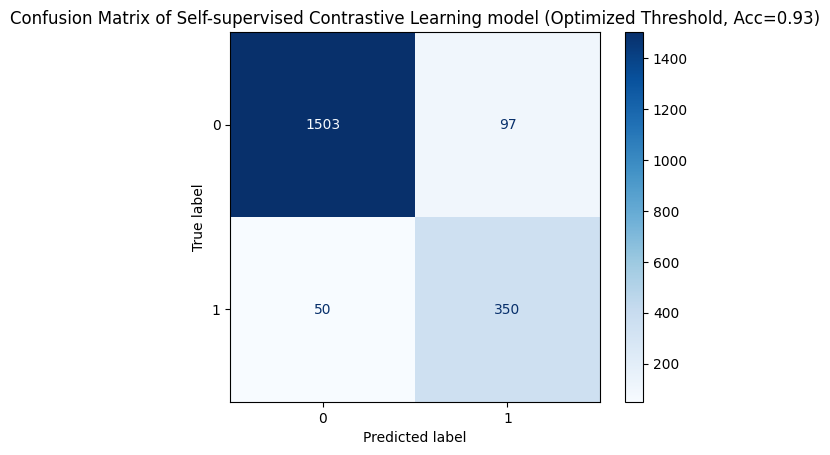

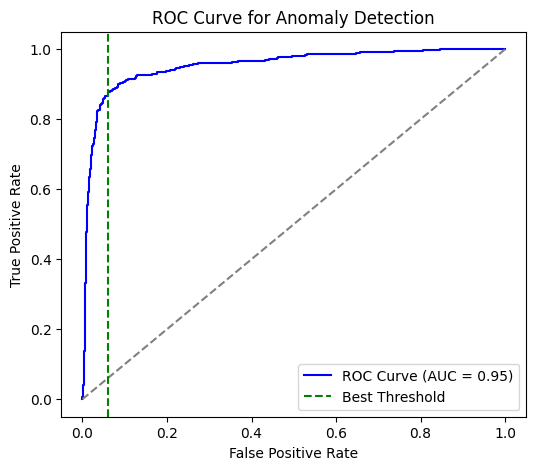

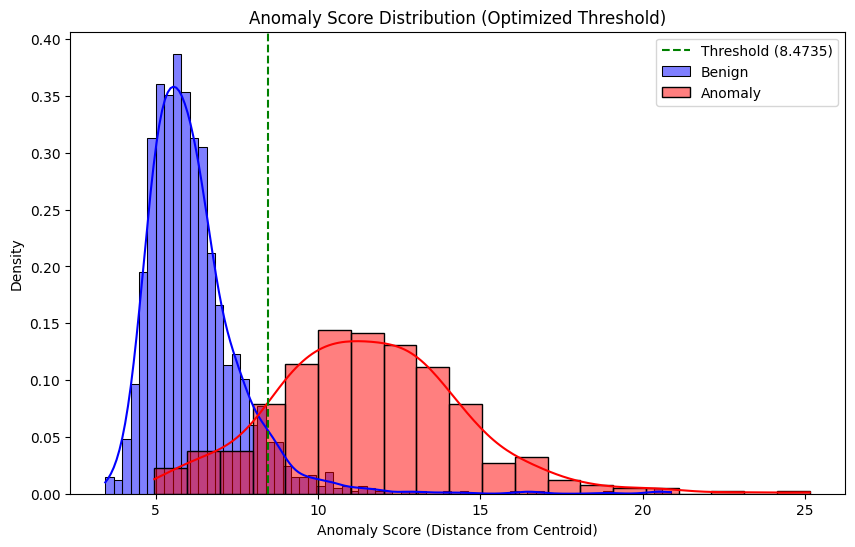

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Start runtime measurement
start_time = time.time()

# Compute anomaly scores
model.eval()
with torch.no_grad():
    # Training embeddings
    train_embeddings = np.vstack([
        model.encoder(data_batch).cpu().numpy() for data_batch, in unlabeled_loader
    ])
    centroid = np.mean(train_embeddings, axis=0)

    # Test embeddings
    test_embeddings = np.vstack([
        model.encoder(data_batch).cpu().numpy() for data_batch, _ in test_loader
    ])

# Compute anomaly scores (Euclidean distance from centroid)
anomaly_scores = np.linalg.norm(test_embeddings - centroid, axis=1)

# Compute ROC and find best threshold
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores)
roc_auc = auc(fpr, tpr)

# Method 1: Youden’s J statistic (best balance between TPR & FPR)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

# Optional: Adjust threshold to reach ~1.5% error rate


# Predict using chosen threshold
y_pred = (anomaly_scores > best_threshold).astype(int)

# Compute accuracy and error rate
proposed_Model_accuracy = np.mean(y_pred == y_test)
proposed_Model_error_rate = 1 - proposed_Model_accuracy

# End runtime measurement
end_time = time.time()
elapsed_time = end_time - start_time

print(f"ROC-AUC of Self-supervised Contrastive Learning model: {roc_auc:.4f}")
print(f"Optimal Threshold of Self-supervised Contrastive Learning model: {best_threshold:.4f}")
print(f"Model Accuracy of Self-supervised Contrastive Learning model: {proposed_Model_accuracy:.4f}")
print(f"Test Error Rate of Self-supervised Contrastive Learning model: {proposed_Model_error_rate:.4f}")
print(f"Runtime of Self-supervised Contrastive Learning model: {elapsed_time:.2f} seconds")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix of Self-supervised Contrastive Learning model (Optimized Threshold, Acc={proposed_Model_accuracy:.2f})")
plt.show()

# ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0,1],[0,1],'--', color='gray')
plt.axvline(fpr[best_idx], color='green', linestyle='--', label='Best Threshold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.show()

# Anomaly Score Distribution
plt.figure(figsize=(10,6))
sns.histplot(anomaly_scores[y_test==0], color='blue', label='Benign', kde=True, stat="density")
sns.histplot(anomaly_scores[y_test==1], color='red', label='Anomaly', kde=True, stat="density")
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Threshold ({best_threshold:.4f})')
plt.title("Anomaly Score Distribution (Optimized Threshold)")
plt.xlabel("Anomaly Score (Distance from Centroid)")
plt.ylabel("Density")
plt.legend()
plt.show()


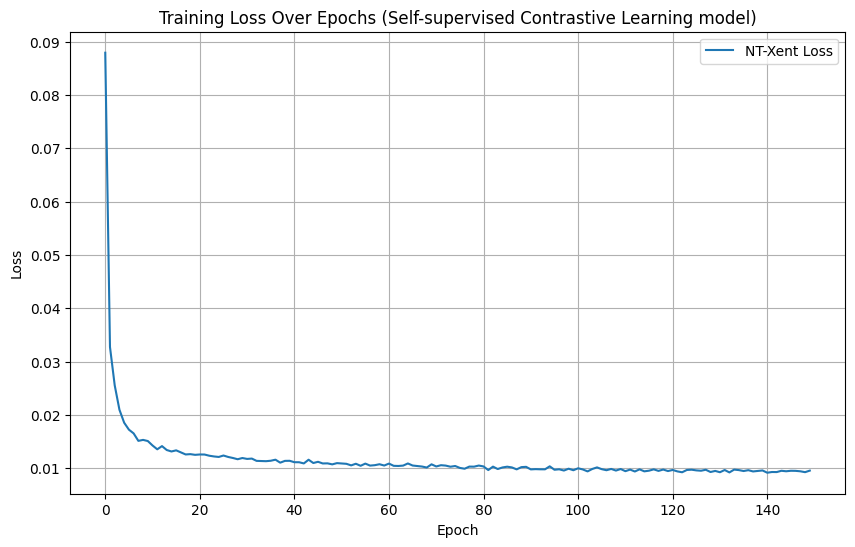

In [ ]:
# Model Loss Visualization
# The Model loss signifies the incorrect prediction made by the Model during training(At each training step: Epochs means the number of training steps)
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='NT-Xent Loss')
plt.title('Training Loss Over Epochs (Self-supervised Contrastive Learning model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Existing Model (CNN-LSTM baseline)

In [ ]:
# Importing the libraries for the LSTM Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Assigning 80% of the dataset for training and 20% of the dataset for testing
train_frac = 0.8
val_frac = 0.2

# Craeting a target variable (0 for Benign and 1 for Anomaly) for the Financial Dataset
benign_fin_idx = df_financial[df_financial.iloc[:, 0] > 0].index
anomaly_fin_idx = df_financial[df_financial.iloc[:, 0] < 0].index

# Spliting and shuffling the Financial Dataset(Synthetic generated dataset)
np.random.seed(42)
train_benign_fin_idx = np.random.choice(benign_fin_idx, size=int(train_frac*len(benign_fin_idx)), replace=False)
val_benign_fin_idx   = np.random.choice(list(set(benign_fin_idx)-set(train_benign_fin_idx)), size=int(val_frac*len(benign_fin_idx)), replace=False)
train_anomaly_fin_idx = np.random.choice(anomaly_fin_idx, size=int(train_frac*len(anomaly_fin_idx)), replace=False)
val_anomaly_fin_idx   = np.random.choice(list(set(anomaly_fin_idx)-set(train_anomaly_fin_idx)), size=int(val_frac*len(anomaly_fin_idx)), replace=False)

# Creating the DataFrames
train_benign_fin = df_financial.loc[train_benign_fin_idx]
val_benign_fin   = df_financial.loc[val_benign_fin_idx]
train_anomaly_fin = df_financial.loc[train_anomaly_fin_idx]
val_anomaly_fin   = df_financial.loc[val_anomaly_fin_idx]

# Splitting the CICIDS Dataset
benign_cicids_idx = cicids_labels[cicids_labels == 0].index
anomaly_cicids_idx = cicids_labels[cicids_labels == 1].index

np.random.seed(42)
train_benign_cicids_idx = np.random.choice(benign_cicids_idx, size=int(train_frac*len(benign_cicids_idx)), replace=False)
val_benign_cicids_idx   = np.random.choice(list(set(benign_cicids_idx)-set(train_benign_cicids_idx)), size=int(val_frac*len(benign_cicids_idx)), replace=False)
train_anomaly_cicids_idx = np.random.choice(anomaly_cicids_idx, size=int(train_frac*len(anomaly_cicids_idx)), replace=False)
val_anomaly_cicids_idx   = np.random.choice(list(set(anomaly_cicids_idx)-set(train_anomaly_cicids_idx)), size=int(val_frac*len(anomaly_cicids_idx)), replace=False)

train_benign_cicids = df_public_source.loc[train_benign_cicids_idx]
val_benign_cicids   = df_public_source.loc[val_benign_cicids_idx]
train_anomaly_cicids = df_public_source.loc[train_anomaly_cicids_idx]
val_anomaly_cicids   = df_public_source.loc[val_anomaly_cicids_idx]

# MERGE Financial Dataset (Synthetic generated dataset) and CICIDS dataset for CNN and LSTM baseline
def merge_data(fin_df, cicids_df):
    min_len = min(len(fin_df), len(cicids_df))
    merged = np.hstack((
        fin_df.sample(min_len, random_state=42).values,
        cicids_df.sample(min_len, random_state=42).values
    ))
    return merged

# The Training Dataset
X_train_benign = merge_data(train_benign_fin, train_benign_cicids)
X_train_anomaly = merge_data(train_anomaly_fin, train_anomaly_cicids)
X_train = np.vstack((X_train_benign, X_train_anomaly))
y_train = np.array([0]*len(X_train_benign) + [1]*len(X_train_anomaly))

# The validation Dataset
X_val_benign = merge_data(val_benign_fin, val_benign_cicids)
X_val_anomaly = merge_data(val_anomaly_fin, val_anomaly_cicids)
X_val = np.vstack((X_val_benign, X_val_anomaly))
y_val = np.array([0]*len(X_val_benign) + [1]*len(X_val_anomaly))

# Displaying the shape of the Training and Testing Dataset
print(f"Training data shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Labels: {y_val.shape}")

Training data shape: (38664, 75), Labels: (38664,)
Validation data shape: (9665, 75), Labels: (9665,)


In [ ]:
# Performing Dataset (i.e., data) normalization using MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Reshaping the Dataset (i.e. data) into 3 x 3 Matrix to be suitable for the LSTM
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_scaled   = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_scaled  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Displaying the reshaped Dataset (i.e., reshaped data)
print(f"Reshaped X_train: {X_train_scaled.shape}")
print(f"Reshaped X_val: {X_val_scaled.shape}")
print(f"Reshaped X_test: {X_test_scaled.shape}")


Reshaped X_train: (38664, 1, 75)
Reshaped X_val: (9665, 1, 75)
Reshaped X_test: (2000, 1, 75)


In [ ]:
# Building the LSTM Architecture by defining the number of layers and setting up the parameters
lstm_model = Sequential([
    LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# Early Stopping Callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │       104,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,769 (440.50 KB)

 Trainable params: 112,769 (440.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the LSTM baseline Model
history = lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9230 - loss: 0.4173 - val_accuracy: 0.8000 - val_loss: 0.5697
Epoch 2/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9785 - loss: 0.0792 - val_accuracy: 0.8000 - val_loss: 0.5480
Epoch 3/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9781 - loss: 0.0716 - val_accuracy: 0.8000 - val_loss: 0.4832
Epoch 4/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9792 - loss: 0.0608 - val_accuracy: 0.8015 - val_loss: 0.3848
Epoch 5/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9782 - loss: 0.0542 - val_accuracy: 0.8600 - val_loss: 0.2649


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Number of misclassified samples of the baseline Model (LSTM): 280/2000
Accuracy of the baseline Model (LSTM): 0.8600
Error Rate of the baseline Model (LSTM): 0.1400
Prediction runtime of LSTM: 0.32 seconds


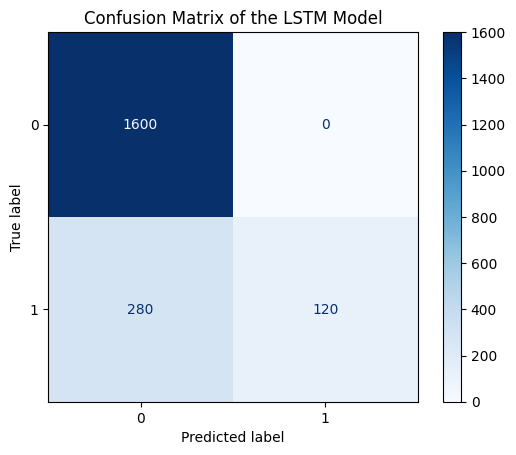

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Declaring variable for computing the runtime of the LSTM Model
start_pred = time.time()
y_pred_prob = lstm_model.predict(X_test_scaled)

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculating the number of misclassified dataset samples
num_wrong = (y_pred != y_test).sum()

# Computing the Total number of test data samples
total_samples = len(y_test)

# Computing the error rate & accuracy of the LSTM Model
lstm_error_rate = num_wrong / total_samples
lstm_accuracy = 1 - lstm_error_rate

print(f"Number of misclassified samples of the baseline Model (LSTM): {num_wrong}/{total_samples}")
print(f"Accuracy of the baseline Model (LSTM): {lstm_accuracy:.4f}")
print(f"Error Rate of the baseline Model (LSTM): {lstm_error_rate:.4f}")

# Computing the end time for the LSTM Model in making a prediction
end_pred = time.time()

# Calculate elapsed time of the LSTM Model
lstm_pred_time = end_pred - start_pred
print(f"Prediction runtime of LSTM: {lstm_pred_time:.2f} seconds")

# Confusion Matrix of the LSTM Model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix of the LSTM Model")
plt.show()

In [ ]:
# Importing libraries for the CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reshaping the input of the CNN Model into 3 x 3 Matrix
X_train_cnn = np.transpose(X_train_scaled, (0, 2, 1))
X_test_cnn = np.transpose(X_test_scaled, (0, 2, 1))

print("CNN Input shape:", X_train_cnn.shape)

# Building the CNN MODEL Architecture
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compiling the CNN MODEL
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping: This help the model to stop after getting the best accuracy
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


CNN Input shape: (38664, 75, 1)


In [ ]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 73, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 36, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 34, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 17, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        17,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,705 (80.88 KB)

 Trainable params: 20,705 (80.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the CNN Model
history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9636 - loss: 0.3192 - val_accuracy: 0.8000 - val_loss: 0.7141
Epoch 2/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9775 - loss: 0.1048 - val_accuracy: 0.8000 - val_loss: 0.6494
Epoch 3/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9772 - loss: 0.0949 - val_accuracy: 0.8000 - val_loss: 0.5472
Epoch 4/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9775 - loss: 0.0769 - val_accuracy: 0.8000 - val_loss: 0.3852
Epoch 5/5
605/605 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9785 - loss: 0.0565 - val_accuracy: 0.8930 - val_loss: 0.2468


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Number of misclassified samples of the baseline Model (CNN): 214/2000
Accuracy of the baseline Model (CNN): 0.8930
Error Rate of the baseline Model (CNN): 0.1070
Prediction runtime of the baseline Model CNN: 0.35 seconds


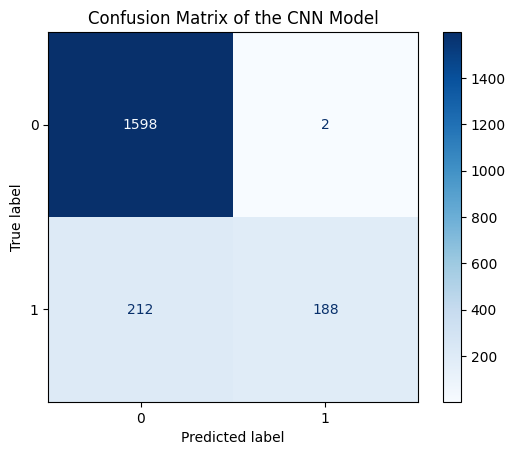

In [ ]:

# Declaring variable for computing the runtime of the CNN Model
start_pred = time.time()
y_pred_prob = cnn_model.predict(X_test_cnn)

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculating the number of misclassified dataset samples
num_wrong = (y_pred != y_test).sum()

# Computing the Total number of test data samples
total_samples = len(y_test)

# Computing the error rate & accuracy of the CNN Model
cnn_error_rate = num_wrong / total_samples
cnn_accuracy = 1 - cnn_error_rate

print(f"Number of misclassified samples of the baseline Model (CNN): {num_wrong}/{total_samples}")
print(f"Accuracy of the baseline Model (CNN): {cnn_accuracy:.4f}")
print(f"Error Rate of the baseline Model (CNN): {cnn_error_rate:.4f}")

# Computing the end time for the CNN Model in making a prediction
end_pred = time.time()

# Calculate elapsed time of the CNN Model
pred_time = end_pred - start_pred
print(f"Prediction runtime of the baseline Model CNN: {pred_time:.2f} seconds")

# Confusion Matrix of the CNN Model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix of the CNN Model")
plt.show()

# Comparison Between the Proposed Self-Supervised Contrastive Learning Model and the CNN-LSTM Baseline Models

# Hypothesis 1 Error Rate:

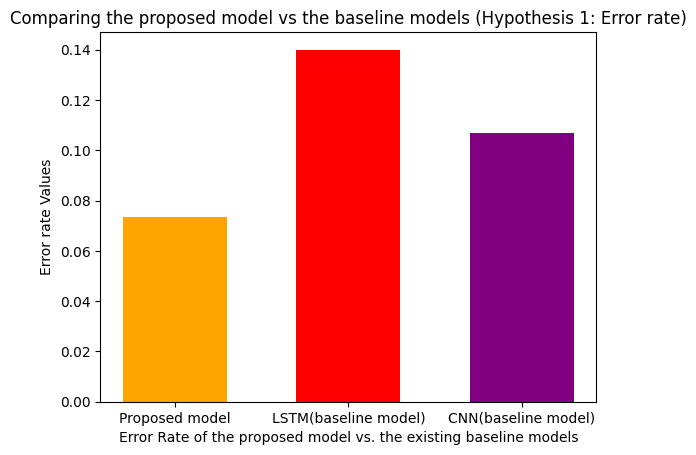

In [ ]:
error_rate = ['Proposed model', 'LSTM(baseline model)', 'CNN(baseline model)']
error_rate_values = [proposed_Model_error_rate, lstm_error_rate, cnn_error_rate]
colors = ['orange', 'red', 'purple']
# Create bar chart
plt.bar(error_rate, error_rate_values, color=colors, width=0.6)

# Add title and labels
plt.title('Comparing the proposed model vs the baseline models (Hypothesis 1: Error rate)')
plt.xlabel('Error Rate of the proposed model vs. the existing baseline models')
plt.ylabel('Error rate Values')

# Show the chart
plt.show()

# Hypothesis 2 Accuracy:



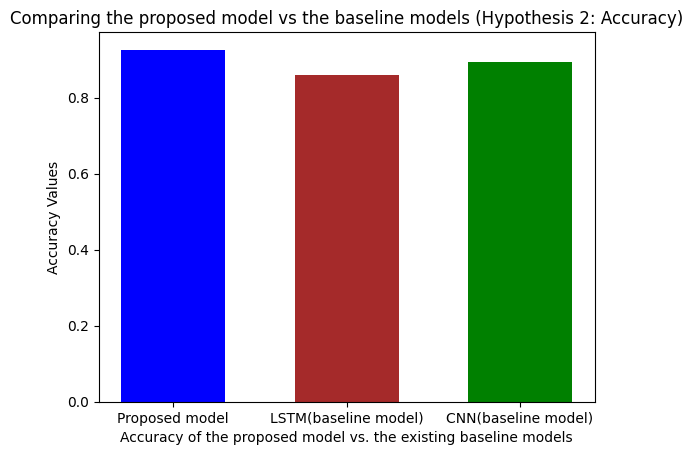

In [ ]:
accuracy = ['Proposed model', 'LSTM(baseline model)', 'CNN(baseline model)']
accuracy_values = [proposed_Model_accuracy, lstm_accuracy, cnn_accuracy]
colors = ['blue', 'brown', 'green']
# Create bar chart
plt.bar(accuracy, accuracy_values, color=colors, width=0.6)

# Add title and labels
plt.title('Comparing the proposed model vs the baseline models (Hypothesis 2: Accuracy)')
plt.xlabel('Accuracy of the proposed model vs. the existing baseline models')
plt.ylabel('Accuracy Values')

# Show the chart
plt.show()

# Hypothesis 3 Runtime:


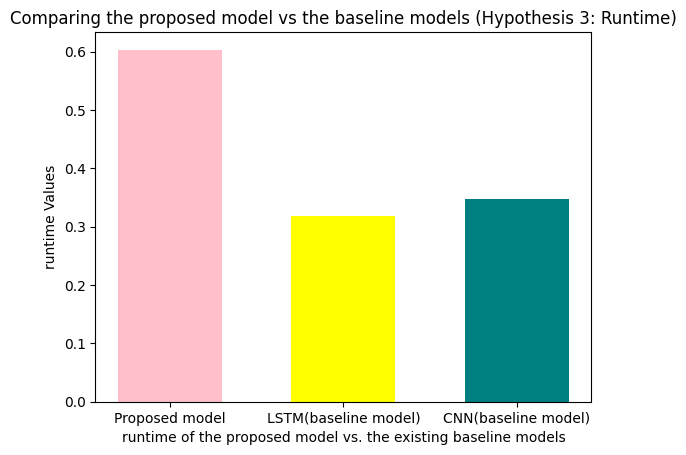

In [ ]:
runtime = ['Proposed model', 'LSTM(baseline model)', 'CNN(baseline model)']
runtime_values = [elapsed_time, lstm_pred_time, pred_time]
colors = ['pink', 'yellow', 'teal']
# Create bar chart
plt.bar(runtime, runtime_values, color=colors, width=0.6)

# Add title and labels
plt.title('Comparing the proposed model vs the baseline models (Hypothesis 3: Runtime)')
plt.xlabel('runtime of the proposed model vs. the existing baseline models')
plt.ylabel('runtime Values')

# Show the chart
plt.show()